# FedGuard — Federated Learning Implementation

```
                    ┌──────────────────────────────────────┐
                    │           FEDERATED SERVER           │
                    │  (a Python object — not a real       │
                    │   separate machine in simulation)    │
                    │                                      │
                    │  holds:  global_weights              │
                    │  does:   FedAvg aggregation          │
                    │          global threshold selection  │
                    └──────┬───────────┬───────────┬───────┘
                           │ sends     │ sends     │ sends
                           │ weights   │ weights   │ weights
                           ▼           ▼           ▼
               ┌──────────────┐ ┌──────────────┐ ┌──────────────┐
               │   CLIENT 1   │ │   CLIENT 2   │ │   CLIENT 3   │
               │  02h–09h59   │ │  10h–17h59   │ │  18h–01h59   │
               │  18,432 rows │ │  18,432 rows │ │  18,432 rows │
               │  (private)   │ │  (private)   │ │  (private)   │
               │              │ │              │ │              │
               │ trains 5 ep  │ │ trains 5 ep  │ │ trains 5 ep  │
               └──────┬───────┘ └──────┬───────┘ └──────┬───────┘
                      │ sends          │ sends          │ sends
                      │ updated        │ updated        │ updated
                      │ weights        │ weights        │ weights
                      └────────────────┴────────────────┘
                                       │
                              Server averages them
                           → new global model weights
                           → next round begins
```

## What physically travels between clients and server
Only model weights (2,033 floats ≈ 8 KB).  
**Raw traffic data never moves. It stays inside each client object forever.**

## This notebook flow
1. Load data → split into 3 temporal client slices  
2. Define the DropoutAutoencoder class  
3. Define the Client class (local training logic)  
4. Define the Server class (FedAvg aggregation)  
5. Run FL: 50 rounds max, early stop on global val loss  
6. Evaluate the global model on the locked test set  
7. Compare FL model vs centralized baseline  
8. Human-in-the-loop confidence scoring  
9. Visualizations

In [1]:
# 0. IMPORTS

import warnings; warnings.filterwarnings('ignore')

import copy
import json
import joblib
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Constants ────────────────────────────────────────────────
FEATURES = [
    'ratio_max_mean_pkts_norm', 'pkts_total_p99_norm',    'bytes_total_p99_norm',
    'proto_udp_share_norm',     'proto_icmp_share_norm',  'syn_ratio_norm',
    'entropy_ip_src_norm',      'pkt_arrivals_avg_p1_norm','pkt_size_avg_p1_norm',
    'heure_sin_norm',           'heure_cos_norm'
]
FEAT_LABELS = [
    'ratio_max_mean','pkts_p99','bytes_p99',
    'udp_share','icmp_share','syn_ratio',
    'entropy','arrivals_p1','size_p1',
    'hour_sin','hour_cos'
]
N_FEAT = len(FEATURES)
N_CLIENTS = 3

OUT = Path('fl_outputs')
OUT.mkdir(exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'Features: {N_FEAT}')
print(f'Clients : {N_CLIENTS}')

Device  : cuda
Features: 11
Clients : 3


In [ ]:
# 1. LOAD DATA

TRAIN_PATH = "dataset_normal_train.csv"
TEST_PATH  = "dataset_test_complet.csv"

df_normal_raw = pd.read_csv(TRAIN_PATH)
df_test_raw   = pd.read_csv(TEST_PATH)

print(f'Normal train : {len(df_normal_raw):,} rows')
print(f'Test         : {len(df_test_raw):,} rows  '
      f'(attack rate {df_test_raw["target"].mean():.1%})')

# ── Check the 'heure' column exists for temporal split ────────
# The preprocessing notebook saved 'heure' in df_normal_raw
# If it is not there, we reconstruct it from window_id
if 'heure' in df_normal_raw.columns:
    print('heure column found — using for temporal split')
elif 'window_id' in df_normal_raw.columns:
    df_normal_raw['heure'] = (df_normal_raw['window_id'] // 3600) % 24
    print('heure reconstructed from window_id')
else:
    # Fallback: assign hour by row position (86400 rows = 24h)
    df_normal_raw['heure'] = (df_normal_raw.index // 3600) % 24
    print('heure assigned by row position (fallback)')

print('\nHour distribution:')
print(df_normal_raw['heure'].value_counts().sort_index())

Normal train : 69,120 rows
Test         : 27,280 rows  (attack rate 36.7%)
heure assigned by row position (fallback)

Hour distribution:
heure
0     3600
1     3600
2     3600
3     3600
4     3600
5     3600
6     3600
7     3600
8     3600
9     3600
10    3600
11    3600
12    3600
13    3600
14    3600
15    3600
16    3600
17    3600
18    3600
19     720
Name: count, dtype: int64


In [4]:
# 2. TEMPORAL DATA SPLIT → 3 CLIENT DATASETS
#
# WHY TEMPORAL SPLIT ??
#
# A random split would give each client nearly identical data
# distributions (near-IID). FL still works but is less interesting
# and less realistic.
#
# A temporal split simulates realistic deployment:
#   Client 1 = a data center running night batch jobs
#   Client 2 = an office network active during business hours
#   Client 3 = an e-commerce platform with evening peak traffic
#
# Each client has a different distribution of:
#   - heure_sin, heure_cos (directly: different time of day)
#   - pkts_p99, bytes_p99  (indirectly: volume differs by hour)
#   - syn_ratio            (indirectly: new connections differ by hour)
#
# This creates mild non-IID (KS ≈ 0.15–0.20), which is the
# scientifically interesting regime FL is designed for.
#
# EACH CLIENT ONLY EVER SEES ITS OWN SLICE.
# Client 1 never sees Client 2's or Client 3's windows.
# ─────────────────────────────────────────────────────────────
CLIENT_HOUR_RANGES = {
    1: list(range(2, 10)),           # 02:00–09:59  night/morning
    2: list(range(10, 18)),          # 10:00–17:59  daytime
    3: list(range(18, 24)) + list(range(0, 2)),  # 18:00–01:59  evening
}

client_dfs = {}
for client_id, hours in CLIENT_HOUR_RANGES.items():
    df_c = df_normal_raw[df_normal_raw['heure'].isin(hours)].copy()
    client_dfs[client_id] = df_c
    print(f'Client {client_id}  hours={hours[:3]}…{hours[-1]:02d}h  '
          f'rows={len(df_c):,}')

# The global test set is shared — all clients are evaluated on the same data
X_test_raw = df_test_raw[FEATURES].values
y_test      = df_test_raw['target'].values

# Split into val_labeled (threshold tuning) and test_final (locked)
X_val_labeled, X_test_final, y_val_labeled, y_test_final = train_test_split(
    X_test_raw, y_test,
    test_size=0.70, stratify=y_test, random_state=SEED
)
print(f'\nval_labeled  : {len(X_val_labeled):,}  attack={y_val_labeled.mean():.1%}')
print(f'test_final   : {len(X_test_final):,}  attack={y_test_final.mean():.1%}  ')

Client 1  hours=[2, 3, 4]…09h  rows=28,800
Client 2  hours=[10, 11, 12]…17h  rows=28,800
Client 3  hours=[18, 19, 20]…01h  rows=11,520

val_labeled  : 8,184  attack=36.7%
test_final   : 19,096  attack=36.7%  


In [5]:
# 3. FIT THE SCALER ON POOLED NORMAL DATA
#
# In a real FL deployment, the scaler would be pre-agreed
# and distributed to all clients before training starts
# (it is a data preprocessing contract, not a model).
#
# We fit it once on ALL normal training data (all 3 clients
# pooled) so that every client normalises its features the
# same way.
# ─────────────────────────────────────────────────────────────
X_all_normal = df_normal_raw[FEATURES].values

scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaler.fit(X_all_normal)
joblib.dump(scaler, OUT / 'fl_scaler.pkl')

# Each client gets its own normalised slice
client_data = {}   

for cid, df_c in client_dfs.items():
    X_raw = df_c[FEATURES].values
    # 90% train, 10% val_normal (for local pct99 threshold)
    X_tr, X_vn = train_test_split(X_raw, test_size=0.10, random_state=SEED)
    client_data[cid] = {
        'X_train'    : scaler.transform(X_tr),
        'X_val_normal': scaler.transform(X_vn),
        'n_train'    : len(X_tr),
    }
    print(f'Client {cid}: train={len(X_tr):,}  val_normal={len(X_vn):,}')

# Also normalise the global evaluation sets
X_val_lbl_pt  = scaler.transform(X_val_labeled)
X_test_final_pt = scaler.transform(X_test_final)

print('\nScaler saved →', OUT / 'fl_scaler.pkl')

Client 1: train=25,920  val_normal=2,880
Client 2: train=25,920  val_normal=2,880
Client 3: train=10,368  val_normal=1,152

Scaler saved → fl_outputs/fl_scaler.pkl


KS statistics between client pairs (0=identical, 1=completely different):
                C1-C2  C1-C3  C2-C3
ratio_max_mean  0.067  0.021  0.054
pkts_p99        0.051  0.012  0.050
bytes_p99       0.055  0.016  0.051
udp_share       0.057  0.015  0.056
icmp_share      0.055  0.019  0.051
syn_ratio       0.254  0.306  0.296
entropy         0.335  0.217  0.452
arrivals_p1     0.050  0.016  0.044
size_p1         0.052  0.016  0.050
hour_sin        0.950  0.728  0.723
hour_cos        0.005  0.948  0.951

Max KS  = 0.951
Mean KS = 0.213
Regime  : strong non-IID (consider FedProx)


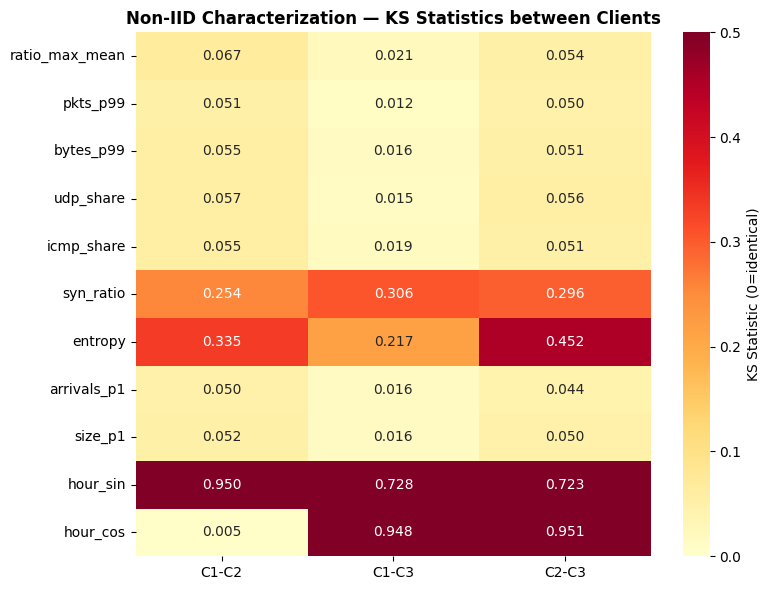

In [6]:
# 4. VERIFY NON-IID CHARACTER WITH KS TEST
#
# The Kolmogorov-Smirnov statistic measures how different two
# distributions are. KS=0 means identical, KS=1 means completely
# different. KS in [0.1, 0.3] is considered "mild non-IID".

from scipy.stats import ks_2samp

pairs = [(1,2), (1,3), (2,3)]
ks_matrix = pd.DataFrame(index=FEAT_LABELS, columns=[f'C{a}-C{b}' for a,b in pairs])

for a, b in pairs:
    Xa = client_data[a]['X_train']
    Xb = client_data[b]['X_train']
    for j, feat in enumerate(FEAT_LABELS):
        ks_stat, _ = ks_2samp(Xa[:, j], Xb[:, j])
        ks_matrix.loc[feat, f'C{a}-C{b}'] = round(ks_stat, 3)

ks_matrix = ks_matrix.astype(float)
max_ks = ks_matrix.values.max()
mean_ks = ks_matrix.values.mean()

print('KS statistics between client pairs (0=identical, 1=completely different):')
print(ks_matrix.to_string())
print(f'\nMax KS  = {max_ks:.3f}')
print(f'Mean KS = {mean_ks:.3f}')

if max_ks < 0.05:
    regime = 'near-IID (consider stronger split)'
elif max_ks < 0.30:
    regime = 'mild non-IID (ideal FL regime)'
else:
    regime = 'strong non-IID (consider FedProx)'

print(f'Regime  : {regime}')

# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ks_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=0.5, ax=ax,
            cbar_kws={'label': 'KS Statistic (0=identical)'})
ax.set_title('Non-IID Characterization — KS Statistics between Clients',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'noniid_ks.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 5. MODEL ARCHITECTURE
#    (same class used by server AND every client )

class DropoutAutoencoder(nn.Module):
    """
    Symmetric Autoencoder  11→32→16→6→16→32→11
    Activation : Tanh   (zero-centred, smooth, bounded)
    Dropout    : p=0.2  (structural regularisation, FL-safe)
    Parameters : 2,033
    """
    def __init__(self, input_dim=11, hidden=32, latent=6, p=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, 16),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(16, latent),        nn.Tanh(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 16),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(16, hidden),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


@torch.no_grad()
def compute_scores(model, X_pt):
    """Per-sample MSE reconstruction error (anomaly score)."""
    model.eval()
    T = torch.FloatTensor(X_pt).to(DEVICE)
    return ((T - model(T)) ** 2).mean(dim=1).cpu().numpy()


def count_params(model):
    return sum(p.numel() for p in model.parameters())


demo = DropoutAutoencoder(N_FEAT)
print(f'Architecture : {N_FEAT}→32→16→6→16→32→{N_FEAT}')
print(f'Parameters   : {count_params(demo):,}')
del demo

Architecture : 11→32→16→6→16→32→11
Parameters   : 2,033


In [8]:
# 6. FL CLIENT CLASS
#
# A Client object holds:
#   - its own private data (never shared)
#   - a local copy of the model
#
# A Client can:
#   - receive new global weights from the server  (set_weights)
#   - train locally for E epochs                  (local_train)
#   - send its updated weights to the server      (get_weights)
#   - compute its local pct99 threshold           (get_local_threshold)

class FLClient:
    def __init__(self, client_id, X_train_pt, X_val_normal_pt, device):
        self.id          = client_id
        self.X_train     = X_train_pt        # private — never shared
        self.X_val_normal = X_val_normal_pt  # private — only for local threshold
        self.n_samples   = len(X_train_pt)
        self.device      = device
        self.model       = DropoutAutoencoder(N_FEAT).to(device)

    # ── Receive weights from server ───────────────────────────
    def set_weights(self, global_weights):
        """
        Load a copy of the global model weights into the local model.
        This happens at the START of every FL round.
        'copy.deepcopy' ensures we do not modify the server's weights
        when we later update the local model.
        """
        self.model.load_state_dict(copy.deepcopy(global_weights))

    # ── Send weights to server ────────────────────────────────
    def get_weights(self):
        """
        Return the current local model weights (after local training).
        This is the ONLY thing that leaves the client.
        """
        return copy.deepcopy(self.model.state_dict())

    # ── Local training ────────────────────────────────────────
    def local_train(self, n_epochs=5, lr=1e-3, wd=1e-5, batch_size=512):
        """
        Train the local model on PRIVATE data for n_epochs epochs.
        Returns the training loss history.

        Key point: we START from the global weights received in
        set_weights(). We do NOT restart from random every round.
        This is how FedAvg works — clients fine-tune the global model.
        """
        T = torch.FloatTensor(self.X_train).to(self.device)
        loader = DataLoader(
            TensorDataset(T, T),
            batch_size=batch_size, shuffle=True, drop_last=False
        )
        opt  = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=wd)
        crit = nn.MSELoss()

        self.model.train()
        local_losses = []
        for _ in range(n_epochs):
            ep_loss = 0.0
            for xb, yb in loader:
                opt.zero_grad()
                loss = crit(self.model(xb), yb)
                loss.backward()
                opt.step()
                ep_loss += loss.item()
            local_losses.append(ep_loss / len(loader))

        self.model.eval()
        return local_losses

    # ── Local threshold ───────────────────────────────────────
    def get_local_threshold(self, percentile=99):
        """pct99 threshold computed on THIS client's normal val data."""
        scores = compute_scores(self.model, self.X_val_normal)
        return float(np.percentile(scores, percentile))

    # ── Local val loss (for monitoring) ──────────────────────
    @torch.no_grad()
    def get_val_loss(self):
        self.model.eval()
        T = torch.FloatTensor(self.X_val_normal).to(self.device)
        return nn.MSELoss()(self.model(T), T).item()


print('FLClient class defined.')

FLClient class defined.


In [9]:
# 7. FL SERVER CLASS
#
# The Server holds the GLOBAL model and performs FedAvg.
#
# FedAvg formula:
#   global_weights = Σ_k  (n_k / N_total) × client_k_weights
#
# n_k = number of training samples on client k
# N_total = total samples across all clients
#
# Clients with more data contribute MORE to the average.
# This is fair: a client with 20,000 samples has "seen more"
# of the normal distribution and should have more influence.

class FLServer:
    def __init__(self, device):
        self.device = device
        # Initialize global model with random weights (same seed for reproducibility)
        torch.manual_seed(SEED)
        self.global_model = DropoutAutoencoder(N_FEAT).to(device)
        self.global_model.eval()

    def get_global_weights(self):
        """Return current global model weights to send to clients."""
        return copy.deepcopy(self.global_model.state_dict())

    def fedavg(self, client_weights_list, client_n_samples):
        """
        Aggregate client weights using FedAvg (McMahan et al. 2017).

        client_weights_list : list of state_dicts, one per client
        client_n_samples    : list of int, training set size per client

        The global weight for each parameter is:
            w_global[param] = Σ_k (n_k / N) * w_k[param]
        """
        N_total = sum(client_n_samples)
        # Start with zero weights
        avg_weights = copy.deepcopy(client_weights_list[0])
        for key in avg_weights:
            avg_weights[key] = torch.zeros_like(avg_weights[key], dtype=torch.float32)

        # Weighted sum
        for weights, n_k in zip(client_weights_list, client_n_samples):
            frac = n_k / N_total
            for key in avg_weights:
                avg_weights[key] += frac * weights[key].float()

        # Load into global model
        self.global_model.load_state_dict(avg_weights)
        self.global_model.eval()

    def get_global_val_loss(self, X_val_normal_pt):
        """Global model's reconstruction loss on a normal validation set."""
        T = torch.FloatTensor(X_val_normal_pt).to(self.device)
        with torch.no_grad():
            return nn.MSELoss()(self.global_model(T), T).item()

    def compute_youden_threshold(self, X_val_labeled_pt, y_val_labeled):
        """Youden J threshold on labeled validation data."""
        scores = compute_scores(self.global_model, X_val_labeled_pt)
        fpr_arr, tpr_arr, thr_arr = roc_curve(y_val_labeled, scores)
        j_vals   = tpr_arr - fpr_arr
        best_idx = int(np.argmax(j_vals))
        return float(thr_arr[best_idx]), scores, fpr_arr, tpr_arr


print('FLServer class defined.')

FLServer class defined.


In [10]:
# 8. INSTANTIATE CLIENTS AND SERVER

server = FLServer(DEVICE)

clients = {}
for cid in range(1, N_CLIENTS + 1):
    clients[cid] = FLClient(
        client_id      = cid,
        X_train_pt     = client_data[cid]['X_train'],
        X_val_normal_pt= client_data[cid]['X_val_normal'],
        device         = DEVICE,
    )
    print(f'Client {cid}: {clients[cid].n_samples:,} training samples')

# Global normal val set for server-side early stopping
# (concatenation of all clients' val_normal data)
X_global_vnorm = np.concatenate(
    [client_data[cid]['X_val_normal'] for cid in range(1, N_CLIENTS+1)]
)
print(f'Global val_normal: {len(X_global_vnorm):,} rows')

# Total samples (used for weighting in FedAvg)
N_SAMPLES_PER_CLIENT = [clients[cid].n_samples for cid in range(1, N_CLIENTS+1)]

Client 1: 25,920 training samples
Client 2: 25,920 training samples
Client 3: 10,368 training samples
Global val_normal: 6,912 rows


In [11]:
# 9. FEDERATED TRAINING LOOP
#
# Each iteration of this loop = one FL "round".
#
# What happens in ONE round :
#   1. Server sends global weights to all clients
#   2. Each client trains locally for E_LOCAL epochs
#   3. Each client sends updated weights back to server
#   4. Server computes FedAvg → new global model
#   5. Server evaluates global model on global val_normal
#   6. If val loss did not improve for PATIENCE rounds → stop
#
# Hyperparameters (defended):
#   MAX_ROUNDS = 50   → 50 × 5 = 250 equivalent epochs, more than
#                        enough (standalone model converged at 72 ep)
#   E_LOCAL = 5       → standard choice; prevents client drift
#                        while allowing meaningful local progress
#   FL_PATIENCE = 10  → same patience as standalone training

MAX_ROUNDS  = 50
E_LOCAL     = 5
FL_PATIENCE = 10
LR          = 1e-3
WD          = 1e-5
BATCH_SIZE  = 512

# Tracking
history = {
    'global_val_loss' : [],
    'client_val_loss' : {cid: [] for cid in range(1, N_CLIENTS+1)},
    'client_train_loss': {cid: [] for cid in range(1, N_CLIENTS+1)},
    'rounds_run'      : 0,
}

best_global_val = float('inf')
patience_ctr    = 0
best_global_weights = None

print('=' * 65)
print('FEDERATED TRAINING')
print(f'  {N_CLIENTS} clients  |  {E_LOCAL} local epochs/round  |  '
      f'max {MAX_ROUNDS} rounds')
print('=' * 65)

for rnd in range(1, MAX_ROUNDS + 1):

    # ── STEP 1: Server broadcasts global weights to all clients ──
    global_weights = server.get_global_weights()
    for cid, client in clients.items():
        client.set_weights(global_weights)

    # ── STEP 2: Each client trains locally ─────────────────────
    client_weights_this_round = []
    for cid, client in clients.items():
        local_loss_hist = client.local_train(
            n_epochs=E_LOCAL, lr=LR, wd=WD, batch_size=BATCH_SIZE
        )
        # Track: average loss over the E_LOCAL epochs
        history['client_train_loss'][cid].append(np.mean(local_loss_hist))
        history['client_val_loss'][cid].append(client.get_val_loss())
        # Collect weights to send to server
        client_weights_this_round.append(client.get_weights())

    # ── STEP 3: Server aggregates (FedAvg) ─────────────────────
    server.fedavg(client_weights_this_round, N_SAMPLES_PER_CLIENT)

    # ── STEP 4: Server evaluates global model ─────────────────
    global_val = server.get_global_val_loss(X_global_vnorm)
    history['global_val_loss'].append(global_val)
    history['rounds_run'] = rnd

    # ── STEP 5: Early stopping ─────────────────────────────────
    if global_val < best_global_val:
        best_global_val     = global_val
        patience_ctr        = 0
        best_global_weights = server.get_global_weights()
    else:
        patience_ctr += 1

    # Progress print every 5 rounds
    if rnd % 5 == 0 or rnd == 1:
        client_vals = [history['client_val_loss'][cid][-1]
                       for cid in range(1, N_CLIENTS+1)]
        print(f'  Round {rnd:2d}/{MAX_ROUNDS}  '
              f'global_val={global_val:.5f}  '
              f'client_vals=['
              + ', '.join(f'{v:.4f}' for v in client_vals)
              + f']  patience={patience_ctr}/{FL_PATIENCE}')

    if patience_ctr >= FL_PATIENCE:
        print(f'\n  Early stop at round {rnd}  best_val={best_global_val:.5f}')
        break

# ── Restore best global weights ────────────────────────────────
server.global_model.load_state_dict(best_global_weights)
server.global_model.eval()

best_round = int(np.argmin(history['global_val_loss'])) + 1
print(f'\nTraining complete.')
print(f'Best round : {best_round}  global_val={best_global_val:.6f}')

FEDERATED TRAINING
  3 clients  |  5 local epochs/round  |  max 50 rounds
  Round  1/50  global_val=0.55039  client_vals=[0.4738, 0.2597, 0.4389]  patience=0/10
  Round  5/50  global_val=0.35593  client_vals=[0.2522, 0.1865, 0.2061]  patience=0/10
  Round 10/50  global_val=0.32458  client_vals=[0.2327, 0.1728, 0.1918]  patience=0/10
  Round 15/50  global_val=0.28987  client_vals=[0.1973, 0.1279, 0.1778]  patience=0/10
  Round 20/50  global_val=0.28888  client_vals=[0.1957, 0.1259, 0.1776]  patience=1/10
  Round 25/50  global_val=0.28766  client_vals=[0.1916, 0.1242, 0.1773]  patience=0/10
  Round 30/50  global_val=0.28659  client_vals=[0.1902, 0.1226, 0.1765]  patience=0/10
  Round 35/50  global_val=0.28460  client_vals=[0.1867, 0.1222, 0.1773]  patience=0/10
  Round 40/50  global_val=0.28431  client_vals=[0.1866, 0.1215, 0.1766]  patience=0/10
  Round 45/50  global_val=0.28551  client_vals=[0.1863, 0.1217, 0.1765]  patience=2/10
  Round 50/50  global_val=0.28457  client_vals=[0.1866, 

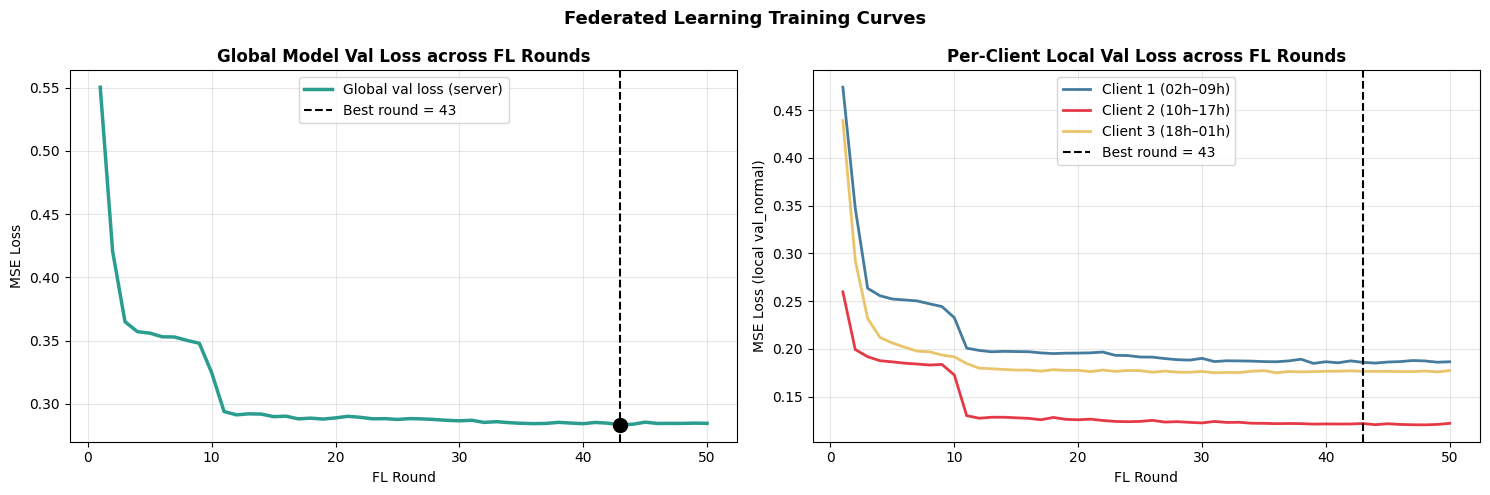

In [12]:
# 10. LEARNING CURVES — GLOBAL AND PER CLIENT

rounds = range(1, history['rounds_run'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Global val loss ───────────────────────────────────────────
ax = axes[0]
ax.plot(rounds, history['global_val_loss'],
        lw=2.5, color='#2A9D8F', label='Global val loss (server)')
ax.axvline(best_round, color='black', ls='--', lw=1.5,
           label=f'Best round = {best_round}')
ax.scatter(best_round, best_global_val, s=100, zorder=5, color='black')
ax.set_xlabel('FL Round')
ax.set_ylabel('MSE Loss')
ax.set_title('Global Model Val Loss across FL Rounds', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Per-client val loss ───────────────────────────────────────
ax = axes[1]
colors = ['#457B9D', '#E63946', '#E9C46A']
for cid, c in zip(range(1, N_CLIENTS+1), colors):
    hours_label = {1:'02h–09h', 2:'10h–17h', 3:'18h–01h'}[cid]
    ax.plot(rounds, history['client_val_loss'][cid],
            lw=2, color=c, label=f'Client {cid} ({hours_label})')
ax.axvline(best_round, color='black', ls='--', lw=1.5,
           label=f'Best round = {best_round}')
ax.set_xlabel('FL Round')
ax.set_ylabel('MSE Loss (local val_normal)')
ax.set_title('Per-Client Local Val Loss across FL Rounds', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Federated Learning Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fl_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 11. THRESHOLD SELECTION FOR THE GLOBAL MODEL

# pct99 — from the global val_normal (no labels needed)
scores_global_vnorm = compute_scores(server.global_model, X_global_vnorm)
t_pct99_fl = float(np.percentile(scores_global_vnorm, 99))

# Youden J — from val_labeled (labeled data, server-side)
t_youden_fl, scores_vlbl, fpr_arr, tpr_arr = \
    server.compute_youden_threshold(X_val_lbl_pt, y_val_labeled)

print(f'FL global thresholds:')
print(f'  pct99    : {t_pct99_fl:.6f}')
print(f'  Youden J : {t_youden_fl:.6f}')

# Also compute local thresholds per client
# (each client calibrates from its own val_normal data)
print('\nLocal thresholds (pct99 on each client\'s own val_normal):')
for cid, client in clients.items():
    # Give client the best global weights first
    client.set_weights(best_global_weights)
    lt = client.get_local_threshold(99)
    print(f'  Client {cid}: {lt:.6f}')

FL global thresholds:
  pct99    : 1.079202
  Youden J : 11.310093

Local thresholds (pct99 on each client's own val_normal):
  Client 1: 1.610872
  Client 2: 0.627549
  Client 3: 0.984339


In [14]:
# 12. FINAL EVALUATION ON LOCKED TEST SET

scores_test_fl = compute_scores(server.global_model, X_test_final_pt)

def eval_full(scores, y, threshold, label):
    pred = (scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {
        'label'    : label,
        'threshold': round(threshold, 6),
        'AUC-ROC'  : round(roc_auc_score(y, scores), 4),
        'F1'       : round(f1_score(y, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y, pred, zero_division=0), 4),
        'Precision': round(precision_score(y, pred, zero_division=0), 4),
        'FPR'      : round(fpr_rate, 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

result_fl_youden = eval_full(scores_test_fl, y_test_final, t_youden_fl, 'FL (Youden J)')
result_fl_pct99  = eval_full(scores_test_fl, y_test_final, t_pct99_fl,  'FL (pct99)')

results = [result_fl_youden, result_fl_pct99]

# ── Print table ───────────────────────────────────────────────
print('=' * 72)
print('FINAL EVALUATION — test_final (LOCKED)')
print('=' * 72)
print(f"  {'Model':<22} {'AUC':>6} {'F1':>7} {'Recall':>8} "
      f"{'Prec':>8} {'FPR':>7}")
print('  ' + '-' * 60)
for r in results:
    print(f"  {r['label']:<22} {r['AUC-ROC']:>6.4f} {r['F1']:>7.4f} "
          f"{r['Recall']:>8.4f} {r['Precision']:>8.4f} {r['FPR']:>7.4f}")
print('=' * 72)

FINAL EVALUATION — test_final (LOCKED)
  Model                     AUC      F1   Recall     Prec     FPR
  ------------------------------------------------------------
  FL (Youden J)          1.0000  0.9999   0.9997   1.0000  0.0000
  FL (pct99)             1.0000  0.9890   1.0000   0.9783  0.0128


In [ ]:
# 13. COMPARE FL vs CENTRALIZED BASELINE

from pathlib import Path
import torch
import inspect
import matplotlib.pyplot as plt

central_path = Path(' fedguard_ae.pt ')

if central_path.exists():
    ckpt = torch.load(central_path, map_location=DEVICE)

    # ── Robust architecture loading (handles mismatches) ──────
    arch = ckpt.get('architecture', {}).copy()

    # Keep only parameters that exist in current model
    valid_params = inspect.signature(DropoutAutoencoder).parameters
    arch = {k: v for k, v in arch.items() if k in valid_params}

    # Optional: warn if something was dropped (good for debugging)
    dropped = set(ckpt.get('architecture', {}).keys()) - set(arch.keys())
    if dropped:
        print(f"[Warning] Ignored unsupported parameters: {dropped}")

    central_model = DropoutAutoencoder(**arch).to(DEVICE)
    central_model.load_state_dict(ckpt['model_state_dict'])
    central_model.eval()

    # ── Inference ─────────────────────────────────────────────
    scores_central = compute_scores(central_model, X_test_final_pt)
    t_central = ckpt['thresholds']['youden_j']

    result_central = eval_full(
        scores_central,
        y_test_final,
        t_central,
        'Centralized (Youden J)'
    )
    results.append(result_central)

    # ── Comparison plot ───────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    metric_pairs = [
        ('F1', 'F1 Score'),
        ('Recall', 'Recall (TPR)'),
        ('FPR', 'False Positive Rate'),
    ]

    labels = ['FL\n(Youden J)', 'FL\n(pct99)', 'Centralized\n(Youden J)']
    plot_results = [result_fl_youden, result_fl_pct99, result_central]
    bar_colors = ['#2A9D8F', '#E9C46A', '#457B9D']

    for ax, (metric_key, metric_title) in zip(axes, metric_pairs):
        vals = [r[metric_key] for r in plot_results]

        bars = ax.bar(
            labels,
            vals,
            color=bar_colors,
            alpha=0.85,
            edgecolor='white'
        )

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.4f}',
                ha='center',
                fontsize=9,
                fontweight='bold'
            )

        ax.set_ylim([0, 1.12])
        ax.set_title(metric_title, fontweight='bold')
        ax.grid(alpha=0.3, axis='y')

    plt.suptitle(
        'FL vs Centralized Model — test_final',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(OUT / 'fl_vs_central.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Privacy cost analysis ─────────────────────────────────
    f1_gap = result_central['F1'] - result_fl_youden['F1']

    print(f'\nFL vs Centralized performance gap (F1): {f1_gap:+.4f}')

    if abs(f1_gap) < 0.01:
        print('  → Gap < 0.01: FL achieves near-identical performance while preserving privacy.')
    elif f1_gap > 0:
        print(f'  → Centralized is better by {f1_gap:.4f}. This is the "privacy cost" of FL.')
    else:
        print(f'  → FL outperforms centralized by {-f1_gap:.4f}. Federation helped (reduced overfitting).')

else:
    print(f'Centralized model not found at {central_path}')
    print('Run fedguard_autoencoder.ipynb first to generate the baseline.')

Centralized model not found at /kaggle/input/datasets/eyakhlifi/fedguard-outputs/fedguard_ae.pt 
Run fedguard_autoencoder.ipynb first to generate the baseline.


Human-in-the-loop routing  (k=2.0):
  Auto-pass    (conf < 0.3)  : 12,097  (63.3%)
  Human review                   :      2  (0.0%)
  Auto-alert   (conf > 0.7)  :  6,997  (36.6%)

Of the 7,000 true attacks:
  Auto-alert zone : 6,997 attacks auto-detected
  Human-review zone:    2 attacks routed to analyst
  Auto-pass zone  :     1 attacks missed (FN)


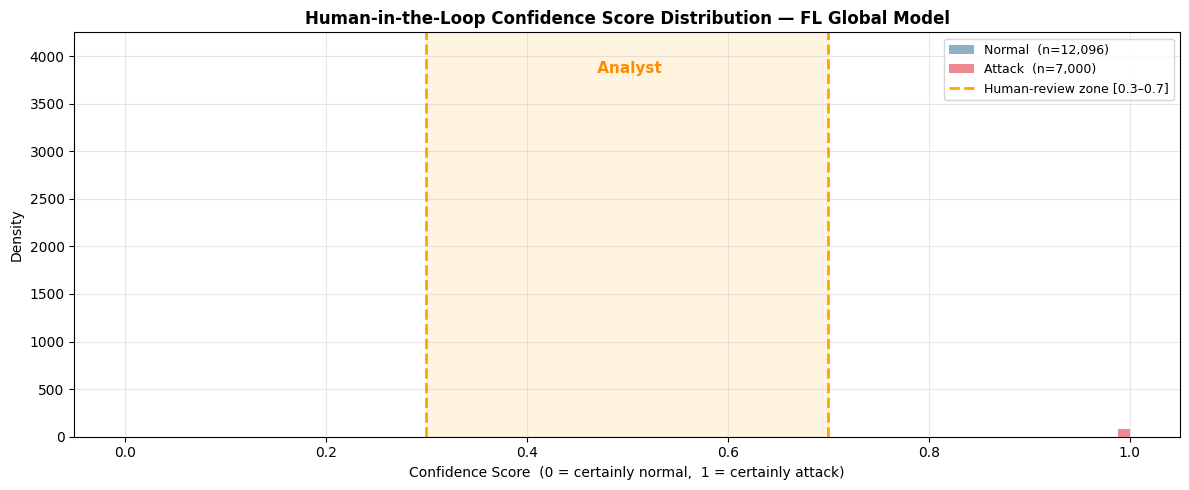

In [17]:
# 14. HUMAN-IN-THE-LOOP CONFIDENCE SCORING
#
# The raw MSE score is converted to a [0,1] confidence:
#   confidence = sigmoid(k × (score − threshold))
#
# Three zones:
#   [0, LOW_CONF)  → auto-pass  (almost certainly normal)
#   [LOW, HIGH]    → human review (ambiguous — route to analyst)
#   (HIGH, 1]      → auto-alert  (almost certainly attack)

K          = 2.0
LOW_CONF   = 0.30
HIGH_CONF  = 0.70

def sigmoid_confidence(scores, threshold, k=2.0):
    return 1.0 / (1.0 + np.exp(-k * (scores - threshold)))

conf = sigmoid_confidence(scores_test_fl, t_youden_fl, k=K)

auto_pass   = conf < LOW_CONF
human_zone  = (conf >= LOW_CONF) & (conf <= HIGH_CONF)
auto_alert  = conf > HIGH_CONF

n_total = len(conf)
print(f'Human-in-the-loop routing  (k={K}):')
print(f'  Auto-pass    (conf < {LOW_CONF})  : '
      f'{auto_pass.sum():>6,}  ({auto_pass.sum()/n_total:.1%})')
print(f'  Human review                   : '
      f'{human_zone.sum():>6,}  ({human_zone.sum()/n_total:.1%})')
print(f'  Auto-alert   (conf > {HIGH_CONF})  : '
      f'{auto_alert.sum():>6,}  ({auto_alert.sum()/n_total:.1%})')

# How many TRUE attacks land in the human zone vs auto-alert?
true_attacks = y_test_final == 1
print(f'\nOf the {true_attacks.sum():,} true attacks:')
print(f'  Auto-alert zone : {(auto_alert & true_attacks).sum():>5,} attacks auto-detected')
print(f'  Human-review zone:{(human_zone & true_attacks).sum():>5,} attacks routed to analyst')
print(f'  Auto-pass zone  : {(auto_pass & true_attacks).sum():>5,} attacks missed (FN)')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(conf[y_test_final==0], bins=60, alpha=0.6, color='#457B9D',
        density=True, label=f'Normal  (n={( y_test_final==0).sum():,})')
ax.hist(conf[y_test_final==1], bins=60, alpha=0.6, color='#E63946',
        density=True, label=f'Attack  (n={(y_test_final==1).sum():,})')
ax.axvspan(LOW_CONF, HIGH_CONF, alpha=0.12, color='orange')
ax.axvline(LOW_CONF,  color='orange', lw=2, ls='--',
           label=f'Human-review zone [{LOW_CONF}–{HIGH_CONF}]')
ax.axvline(HIGH_CONF, color='orange', lw=2, ls='--')
ax.text((LOW_CONF+HIGH_CONF)/2, ax.get_ylim()[1]*0.9,
        ' Analyst', ha='center', fontsize=11, color='darkorange',
        fontweight='bold')
ax.set_xlabel('Confidence Score  (0 = certainly normal,  1 = certainly attack)')
ax.set_ylabel('Density')
ax.set_title('Human-in-the-Loop Confidence Score Distribution — FL Global Model',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'fl_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

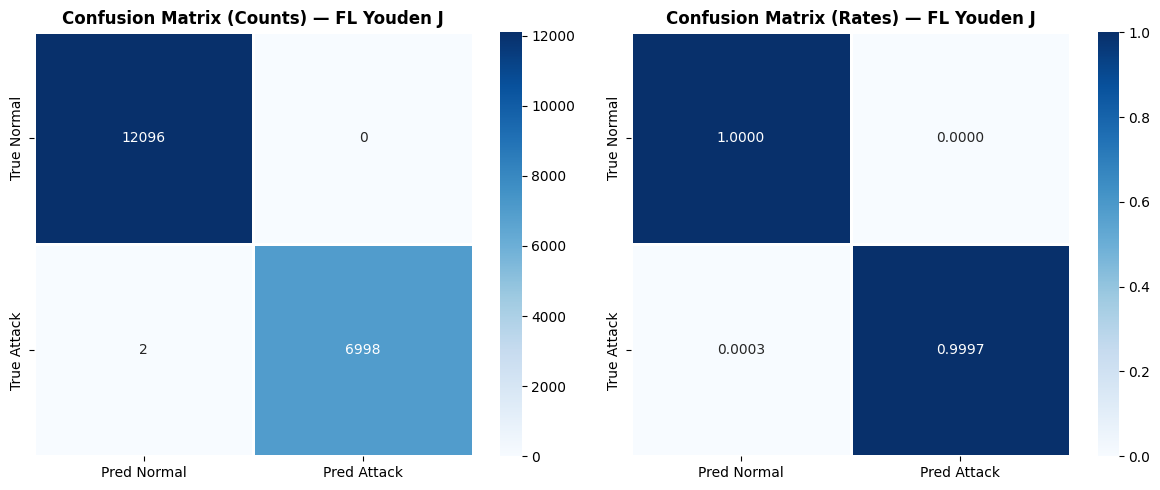

In [18]:
# 15. CONFUSION MATRIX — FL GLOBAL MODEL (Youden J)

pred_fl = (scores_test_fl > t_youden_fl).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_final, pred_fl).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_abs  = np.array([[tn, fp],[fn, tp]])
cm_norm = cm_abs.astype(float)
cm_norm[0] /= cm_norm[0].sum()
cm_norm[1] /= cm_norm[1].sum()

for ax, data, fmt, title in [
    (axes[0], cm_abs,  'd',      'Counts'),
    (axes[1], cm_norm, '.4f',    'Rates'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Pred Normal','Pred Attack'],
                yticklabels=['True Normal','True Attack'],
                linewidths=1, linecolor='white',
                vmin=0, vmax=(None if fmt=='d' else 1))
    ax.set_title(f'Confusion Matrix ({title}) — FL Youden J', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'fl_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 16. SAVE FL MODEL AND RESULTS

torch.save({
    'model_state_dict': server.global_model.state_dict(),
    'architecture'    : {'input_dim': N_FEAT, 'hidden': 32, 'latent': 6, 'p': 0.2},
    'fl_config'       : {
        'n_clients'  : N_CLIENTS,
        'e_local'    : E_LOCAL,
        'max_rounds' : MAX_ROUNDS,
        'best_round' : best_round,
        'fl_patience': FL_PATIENCE,
        'aggregation': 'FedAvg',
        'split'      : 'temporal (02-09h, 10-17h, 18-01h)',
    },
    'thresholds'      : {'pct99': t_pct99_fl, 'youden_j': t_youden_fl},
    'performance'     : {
        'fl_youden': result_fl_youden,
        'fl_pct99' : result_fl_pct99,
    },
    'features'        : FEATURES,
}, OUT / 'fl_global_model.pt')

print('Saved:', OUT / 'fl_global_model.pt')

# ── Final summary ─────────────────────────────────────────────
print('\n' + '=' * 65)
print('FEDGUARD — FL FINAL SUMMARY')
print('=' * 65)
print(f'  N clients          : {N_CLIENTS}  (temporal: 02-09h / 10-17h / 18-01h)')
print(f'  Data split         : non-IID temporal  (KS mean={mean_ks:.3f})')
print(f'  Aggregation        : FedAvg')
print(f'  Local epochs/round : {E_LOCAL}')
print(f'  FL rounds run      : {history["rounds_run"]}  (best={best_round})')
print(f'  Best global val    : {best_global_val:.6f}')
print()
print(f'  DETECTION RESULTS (test_final — LOCKED)')
print(f'  {"Metric":<12} {"FL Youden J":>12} {"FL pct99":>10}')
print(f'  {"-"*36}')
for k in ['AUC-ROC','F1','Recall','Precision','FPR']:
    print(f'  {k:<12} {result_fl_youden[k]:>12.4f} {result_fl_pct99[k]:>10.4f}')
print('=' * 65)

Saved: fl_outputs/fl_global_model.pt

FEDGUARD — FL FINAL SUMMARY
  N clients          : 3  (temporal: 02-09h / 10-17h / 18-01h)
  Data split         : non-IID temporal  (KS mean=0.213)
  Aggregation        : FedAvg
  Local epochs/round : 5
  FL rounds run      : 50  (best=43)
  Best global val    : 0.283393

  DETECTION RESULTS (test_final — LOCKED)
  Metric        FL Youden J   FL pct99
  ------------------------------------
  AUC-ROC            1.0000     1.0000
  F1                 0.9999     0.9890
  Recall             0.9997     1.0000
  Precision          1.0000     0.9783
  FPR                0.0000     0.0128


---
# FedAvg vs FedProx — Algorithm Comparison

## What changes between the two algorithms

| Component | FedAvg | FedProx |
|---|---|---|
| **Local loss** | MSE only | MSE + proximal term |
| **Aggregation** | Weighted average | **Same** weighted average |
| **Extra hyperparameter** | None | μ (proximal coefficient) |

FedProx (Li et al., MLSys 2020) adds one term to the local objective:

$$L_{\text{FedProx}} = \underbrace{\text{MSE}(\hat{x}, x)}_{\text{reconstruction}} + \underbrace{\frac{\mu}{2} \|w_{\text{local}} - w_{\text{global}}\|^2}_{\text{proximal term}}$$

The proximal term acts as a **rubber band** that prevents each client from drifting
too far from the global model during local training.
This helps when data is strongly non-IID.

## What we expect to find
KS mean = 0.213 → **mild non-IID**.  
FedProx is designed for **strong** non-IID where clients would otherwise diverge.  
Expected outcome: both algorithms converge to AUC ≈ 1.000 and F1 ≈ 0.9999.  
The comparison quantifies whether FedProx provides any benefit in this setting.
This is a valid scientific contribution — telling practitioners *when* they need
FedProx and when FedAvg is sufficient.

In [ ]:
# CELL A — FEDPROX LOCAL TRAINING
#
# This is the ONLY thing that changes vs FedAvg.
# The server-side aggregation (FLServer.fedavg) is identical.
#
# How FedProx works:
#   Standard FedAvg local loss:  L = MSE(recon, x)
#   FedProx local loss:          L = MSE(recon, x)
#                                    + (μ/2) * ||w_local - w_global||²
#
# The proximal term ||w_local - w_global||² measures how far
# the local model has drifted from the global model.
# Multiplying by μ/2 controls how strongly we penalise drift.
#
# μ = 0.01: standard starting value from Li et al. (2020).
#   - Too small (μ→0): FedProx → FedAvg (no regularisation)
#   - Too large (μ→∞): local model never moves from global weights
#   - μ = 0.01 gives mild regularisation, appropriate for mild non-IID

MU_PROX = 0.01  # proximal coefficient (Li et al. 2020 recommend tuning in {0.001, 0.01, 0.1})


def local_train_fedprox(model, X_train_pt, global_weights,
                        n_epochs, mu=MU_PROX,
                        lr=1e-3, wd=1e-5, batch_size=512):
    """
    FedProx local training step.

    Parameters
    ----------
    model         : local client model (loaded with global weights before calling)
    X_train_pt    : client's private training data (normalised)
    global_weights: state_dict of the current global model (frozen reference)
    n_epochs      : number of local training epochs
    mu            : proximal coefficient

    Returns
    -------
    updated state_dict, list of per-epoch reconstruction losses
    """
    # Build a frozen copy of the global model to compute the proximal term
    # This reference does NOT get updated — it is a fixed anchor
    global_ref = DropoutAutoencoder(N_FEAT).to(DEVICE)
    global_ref.load_state_dict(copy.deepcopy(global_weights))
    global_ref.eval()
    for param in global_ref.parameters():
        param.requires_grad = False

    T      = torch.FloatTensor(X_train_pt).to(DEVICE)
    loader = DataLoader(TensorDataset(T, T),
                        batch_size=batch_size, shuffle=True, drop_last=False)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit   = nn.MSELoss()

    model.train()
    epoch_losses = []

    for _ in range(n_epochs):
        ep_recon_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()

            # Reconstruction loss (same as FedAvg)
            recon_loss = crit(model(xb), yb)

            # Proximal term: penalise drift from global weights
            # ||w_local - w_global||² summed over all parameters
            proximal = sum(
                ((p_local - p_global) ** 2).sum()
                for p_local, p_global in zip(
                    model.parameters(), global_ref.parameters()
                )
            )

            # Total FedProx loss
            total_loss = recon_loss + (mu / 2.0) * proximal

            total_loss.backward()
            opt.step()

            # Track reconstruction loss only (not the regularisation term)
            # so learning curves are comparable to FedAvg
            ep_recon_loss += recon_loss.item()

        epoch_losses.append(ep_recon_loss / len(loader))

    model.eval()
    return copy.deepcopy(model.state_dict()), epoch_losses


print(f'FedProx local training defined  (μ = {MU_PROX})')
print(f'  Loss = MSE(recon, x)  +  (μ/2) * ||w_local - w_global||²')

FedProx local training defined  (μ = 0.01)
  Loss = MSE(recon, x)  +  (μ/2) * ||w_local - w_global||²


In [ ]:
# CELL B — RUN FEDPROX FL LOOP
#
# Identical loop to the FedAvg section above, except:
#   - local training calls local_train_fedprox() instead of client.local_train()
#   - aggregation is still server.fedavg() — unchanged
#
# Same hyperparameters:
#   MAX_ROUNDS = 50, FL_PATIENCE = 10, E_LOCAL = 5
# Same data splits (clients, X_global_vnorm, etc.)
# Same random seed for fair comparison

import time

# Re-initialise server and client models from scratch
# so FedProx starts from the SAME random weights as FedAvg did
torch.manual_seed(SEED)
server_prox = FLServer(DEVICE)

clients_prox = {}
for cid in range(1, N_CLIENTS + 1):
    clients_prox[cid] = FLClient(
        client_id       = cid,
        X_train_pt      = client_data[cid]['X_train'],
        X_val_normal_pt = client_data[cid]['X_val_normal'],
        device          = DEVICE,
    )

history_prox = {
    'global_val_loss': [],
    'rounds_run'     : 0,
}

best_global_val_prox   = float('inf')
patience_ctr_prox      = 0
best_global_weights_prox = None

print('=' * 65)
print('FEDPROX TRAINING')
print(f'  μ = {MU_PROX}  |  {N_CLIENTS} clients  |  '
      f'{E_LOCAL} local epochs/round  |  max {MAX_ROUNDS} rounds')
print('=' * 65)

t0 = time.time()

for rnd in range(1, MAX_ROUNDS + 1):

    # ── Step 1: Broadcast global weights to all clients ────────
    global_weights_prox = server_prox.get_global_weights()
    for cid in range(1, N_CLIENTS + 1):
        clients_prox[cid].set_weights(global_weights_prox)

    # ── Step 2: Each client trains with FedProx local loss ─────
    client_weights_prox = []
    for cid in range(1, N_CLIENTS + 1):
        updated_w, _ = local_train_fedprox(
            model          = clients_prox[cid].model,
            X_train_pt     = client_data[cid]['X_train'],
            global_weights = global_weights_prox,   # frozen reference
            n_epochs       = E_LOCAL,
            mu             = MU_PROX,
        )
        client_weights_prox.append(updated_w)

    # ── Step 3: Aggregate with FedAvg (unchanged) ─────────────
    # FedProx only changes local training, NOT the aggregation step
    server_prox.fedavg(client_weights_prox, N_SAMPLES_PER_CLIENT)

    # ── Step 4: Evaluate global model ─────────────────────────
    global_val_prox = server_prox.get_global_val_loss(X_global_vnorm)
    history_prox['global_val_loss'].append(global_val_prox)
    history_prox['rounds_run'] = rnd

    # ── Step 5: Early stopping ────────────────────────────────
    if global_val_prox < best_global_val_prox:
        best_global_val_prox    = global_val_prox
        patience_ctr_prox       = 0
        best_global_weights_prox = server_prox.get_global_weights()
    else:
        patience_ctr_prox += 1
        if patience_ctr_prox >= FL_PATIENCE:
            print(f'  Early stop at round {rnd}  '
                  f'best_val={best_global_val_prox:.5f}')
            break

    if rnd % 10 == 0 or rnd == 1:
        print(f'  Round {rnd:2d}/{MAX_ROUNDS}  '
              f'val={global_val_prox:.5f}  '
              f'patience={patience_ctr_prox}/{FL_PATIENCE}')

# Restore best weights
server_prox.global_model.load_state_dict(best_global_weights_prox)
server_prox.global_model.eval()

best_round_prox = int(np.argmin(history_prox['global_val_loss'])) + 1
elapsed = time.time() - t0

print(f'\nFedProx done  best_round={best_round_prox}  '
      f'best_val={best_global_val_prox:.6f}  '
      f'time={elapsed/60:.1f} min')

FEDPROX TRAINING
  μ = 0.01  |  3 clients  |  5 local epochs/round  |  max 50 rounds
  Round  1/50  val=0.56003  patience=0/10
  Round 10/50  val=0.34446  patience=0/10
  Round 20/50  val=0.34711  patience=5/10
  Early stop at round 25  best_val=0.34443

FedProx done  best_round=15  best_val=0.344430  time=1.8 min


In [ ]:
# CELL C — THRESHOLD SELECTION FOR FEDPROX MODEL


@torch.no_grad()
def compute_scores(model, X_pt):
    model.eval()
    T = torch.FloatTensor(X_pt).to(DEVICE)
    return ((T - model(T)) ** 2).mean(dim=1).cpu().numpy()


def eval_full(model, X_val_lbl_pt, y_val_lbl, X_test_pt, y_test, label):
    """
    Compute Youden J threshold from val_labeled,
    then evaluate on the locked test_final.
    """
    # Youden J threshold
    scores_val         = compute_scores(model, X_val_lbl_pt)
    fpr_v, tpr_v, thr_v = roc_curve(y_val_lbl, scores_val)
    best_idx           = int(np.argmax(tpr_v - fpr_v))
    t_youden           = float(thr_v[best_idx])

    # Test evaluation
    scores_test = compute_scores(model, X_test_pt)
    pred        = (scores_test > t_youden).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    return {
        'label'     : label,
        'threshold' : t_youden,
        'AUC-ROC'   : round(roc_auc_score(y_test, scores_test), 4),
        'F1'        : round(f1_score(y_test, pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, pred, zero_division=0), 4),
        'Precision' : round(precision_score(y_test, pred, zero_division=0), 4),
        'FPR'       : round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0.0,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'scores_test': scores_test,
        'fpr_roc': fpr_v, 'tpr_roc': tpr_v,
    }


# ── Evaluate FedAvg (already trained above) ───────────────────
res_fedavg = eval_full(
    server.global_model,
    X_val_lbl_pt, y_val_labeled,
    X_test_final_pt, y_test_final,
    label='FedAvg',
)

# ── Evaluate FedProx (just trained) ──────────────────────────
res_fedprox = eval_full(
    server_prox.global_model,
    X_val_lbl_pt, y_val_labeled,
    X_test_final_pt, y_test_final,
    label='FedProx',
)

print(f"{'Metric':<12}  {'FedAvg':>10}  {'FedProx':>10}")
print('-' * 36)
for k in ['AUC-ROC', 'F1', 'Recall', 'Precision', 'FPR']:
    print(f"{k:<12}  {res_fedavg[k]:>10.4f}  {res_fedprox[k]:>10.4f}")
print('-' * 36)
print(f"{'Threshold':<12}  {res_fedavg['threshold']:>10.4f}  "
      f"{res_fedprox['threshold']:>10.4f}")
print(f"{'Best round':<12}  {best_round:>10}  {best_round_prox:>10}")
print(f"{'Rounds run':<12}  {history['rounds_run']:>10}  "
      f"{history_prox['rounds_run']:>10}")
print(f"{'Best val':<12}  {best_global_val:>10.5f}  "
      f"{best_global_val_prox:>10.5f}")

Metric            FedAvg     FedProx
------------------------------------
AUC-ROC           1.0000      1.0000
F1                0.9999      0.9999
Recall            0.9997      0.9999
Precision         1.0000      1.0000
FPR               0.0000      0.0000
------------------------------------
Threshold        11.3101     11.2336
Best round            43          15
Rounds run            50          25
Best val         0.28339     0.34443


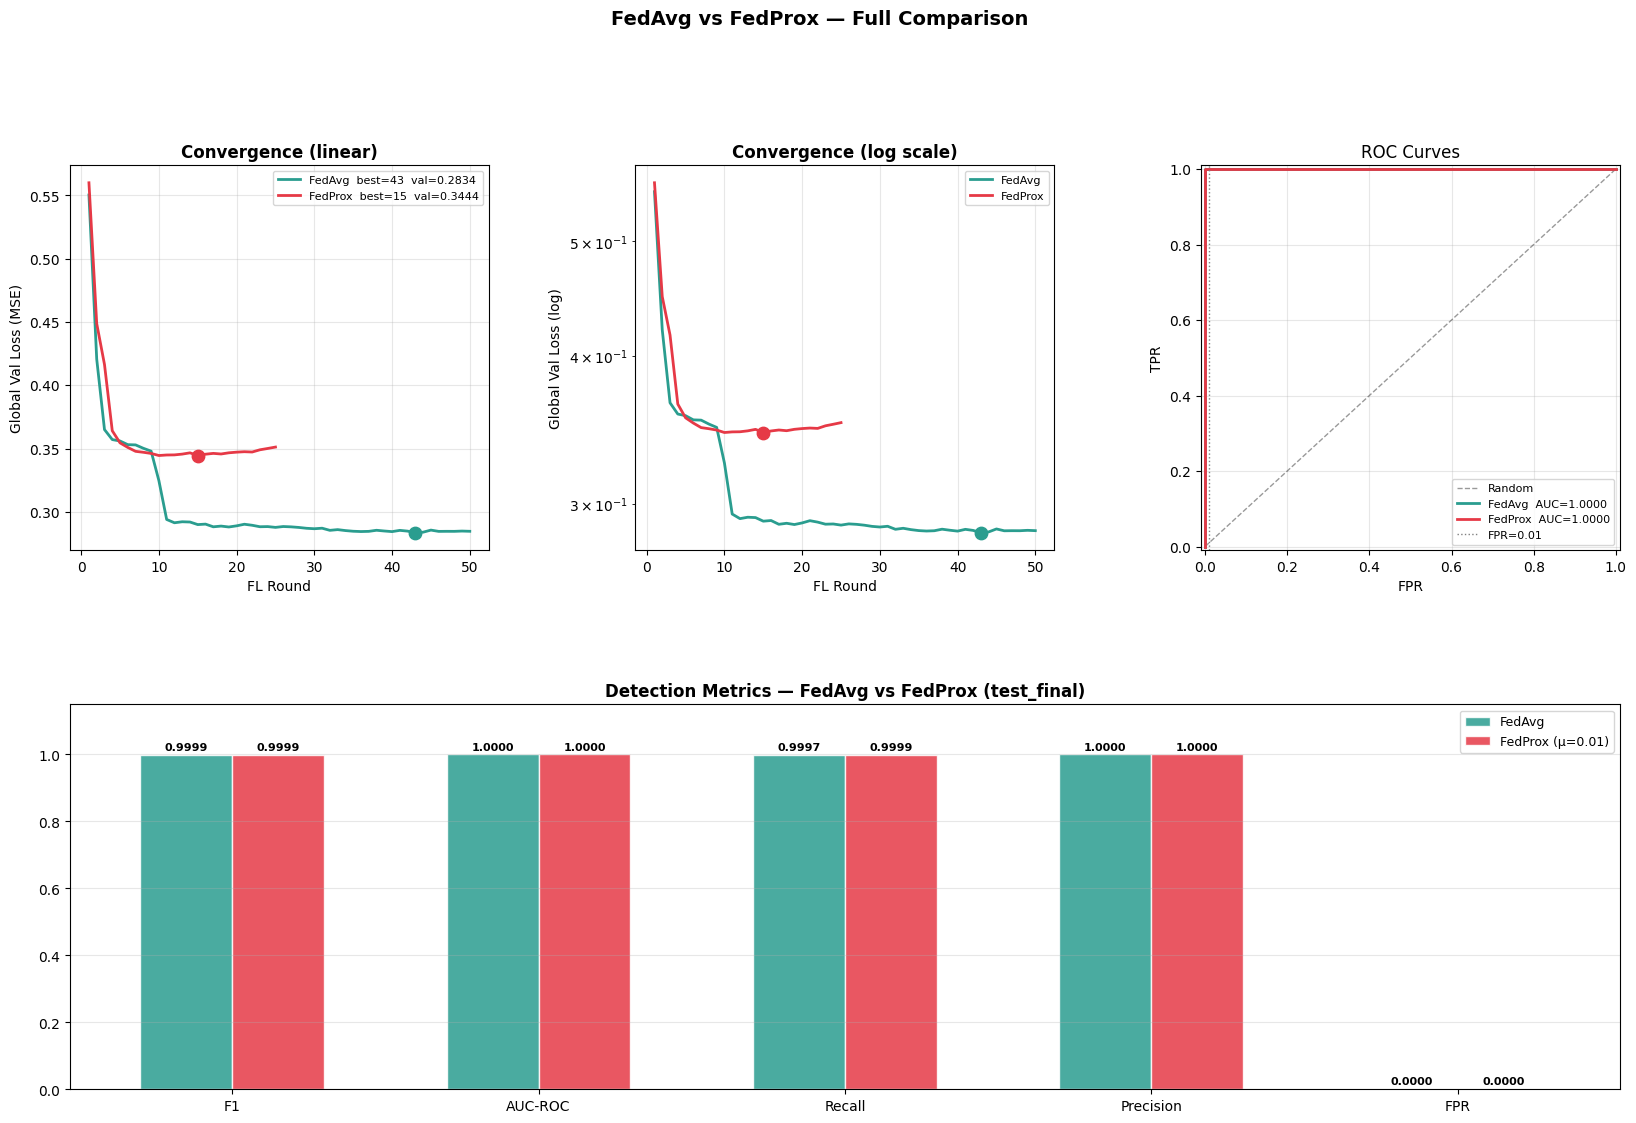

Saved: fl_outputs/fedavg_vs_fedprox.png


In [ ]:
# CELL D — VISUALISATIONS

COLORS = {'FedAvg': '#2A9D8F', 'FedProx': '#E63946'}
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35)

# ── Plot 1: Convergence curves (linear) ───────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for label, hist, br, bv, c in [
    ('FedAvg',  history['global_val_loss'],      best_round,      best_global_val,      COLORS['FedAvg']),
    ('FedProx', history_prox['global_val_loss'], best_round_prox, best_global_val_prox, COLORS['FedProx']),
]:
    rounds = range(1, len(hist) + 1)
    ax1.plot(rounds, hist, lw=2, color=c,
             label=f'{label}  best={br}  val={bv:.4f}')
    ax1.scatter(br, hist[br - 1], s=80, zorder=5, color=c)
ax1.set_xlabel('FL Round'); ax1.set_ylabel('Global Val Loss (MSE)')
ax1.set_title('Convergence (linear)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Plot 2: Convergence curves (log scale) ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for label, hist, br, c in [
    ('FedAvg',  history['global_val_loss'],      best_round,      COLORS['FedAvg']),
    ('FedProx', history_prox['global_val_loss'], best_round_prox, COLORS['FedProx']),
]:
    rounds = range(1, len(hist) + 1)
    ax2.semilogy(rounds, hist, lw=2, color=c, label=label)
    ax2.scatter(br, hist[br - 1], s=80, zorder=5, color=c)
ax2.set_xlabel('FL Round'); ax2.set_ylabel('Global Val Loss (log)')
ax2.set_title('Convergence (log scale)', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Plot 3: ROC curves ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
for res in [res_fedavg, res_fedprox]:
    fpr_r, tpr_r, _ = roc_curve(
        y_test_final, res['scores_test']
    )
    ax3.plot(fpr_r, tpr_r, lw=2, color=COLORS[res['label']],
             label=f"{res['label']}  AUC={res['AUC-ROC']:.4f}")
ax3.axvline(0.01, color='grey', ls=':', lw=1, label='FPR=0.01')
ax3.set(xlabel='FPR', ylabel='TPR', title='ROC Curves',
        xlim=[-0.01,1.01], ylim=[-0.01,1.01])
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── Plot 4: Detection metric bar chart ────────────────────────
metrics_show = ['F1', 'AUC-ROC', 'Recall', 'Precision', 'FPR']
ax4 = fig.add_subplot(gs[1, :])

n_metrics = len(metrics_show)
x         = np.arange(n_metrics)
width     = 0.30

vals_avg  = [res_fedavg[m]  for m in metrics_show]
vals_prox = [res_fedprox[m] for m in metrics_show]

bars1 = ax4.bar(x - width/2, vals_avg,  width,
                color=COLORS['FedAvg'],  alpha=0.85,
                edgecolor='white', label='FedAvg')
bars2 = ax4.bar(x + width/2, vals_prox, width,
                color=COLORS['FedProx'], alpha=0.85,
                edgecolor='white', label=f'FedProx (μ={MU_PROX})')

for bars, vals in [(bars1, vals_avg), (bars2, vals_prox)]:
    for bar, val in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.008,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

ax4.set_xticks(x)
ax4.set_xticklabels(metrics_show, fontsize=10)
ax4.set_ylim([0, 1.15])
ax4.set_title('Detection Metrics — FedAvg vs FedProx (test_final)',
              fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, axis='y')

plt.suptitle('FedAvg vs FedProx — Full Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(OUT / 'fedavg_vs_fedprox.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT / 'fedavg_vs_fedprox.png')

In [25]:
# CELL E — WINNER SELECTION + FULL SUMMARY

# Select winner by F1 score
winner = 'FedAvg' if res_fedavg['F1'] >= res_fedprox['F1'] else 'FedProx'
f1_gap = abs(res_fedavg['F1'] - res_fedprox['F1'])

print('=' * 65)
print('FEDAVG vs FEDPROX — FINAL COMPARISON')
print('=' * 65)

print(f"\n  {'Metric':<14}  {'FedAvg':>10}  {'FedProx':>10}  {'Δ':>8}")
print('  ' + '─' * 46)
for k in ['AUC-ROC', 'F1', 'Recall', 'Precision', 'FPR']:
    delta = res_fedprox[k] - res_fedavg[k]
    # For FPR, negative delta means FedProx is better
    arrow = '↑' if (k != 'FPR' and delta > 0) else ('↓' if (k == 'FPR' and delta < 0) else '')
    print(f"  {k:<14}  {res_fedavg[k]:>10.4f}  "
          f"{res_fedprox[k]:>10.4f}  {delta:>+8.4f} {arrow}")

print('  ' + '─' * 46)
print(f"  {'Best round':<14}  {best_round:>10}  {best_round_prox:>10}")
print(f"  {'Rounds run':<14}  {history['rounds_run']:>10}  "
      f"{history_prox['rounds_run']:>10}")
print(f"  {'Best val loss':<14}  {best_global_val:>10.5f}  "
      f"{best_global_val_prox:>10.5f}")

print(f'\n  WINNER: {winner}')

# Scientific interpretation based on the observed gap
print('\n  INTERPRETATION:')
if f1_gap < 0.002:
    print(f'  F1 gap = {f1_gap:.4f} — negligible difference (<0.002).')
    print(f'  Both algorithms reach equivalent detection performance on this dataset.')
    print(f'  The non-IID level (KS mean={mean_ks:.3f}) is mild enough that')
    print(f'  client drift does not significantly degrade FedAvg convergence.')
    print(f'  It s better better to deploy FedAvg — it achieves the same result')
    print(f'  with zero extra hyperparameters and lower computational overhead.')
elif winner == 'FedProx':
    print(f'  F1 gap = {f1_gap:.4f} — FedProx outperforms FedAvg.')
    print(f'  The proximal term (μ={MU_PROX}) successfully reduces client drift,')
    print(f'  suggesting the non-IID level is sufficient to cause divergence.')
    print(f'  It s better better to deploy FedProx with μ={MU_PROX}.')
else:
    print(f'  F1 gap = {f1_gap:.4f} — FedAvg outperforms FedProx.')
    print(f'  The proximal term (μ={MU_PROX}) may be slightly over-constraining')
    print(f'  local training, limiting the model from adapting to client data.')
    print(f'  It s better better to deploy FedAvg. If FedProx is desired, tune μ downward.')

print('=' * 65)

# Save the winner model
winner_model = server.global_model if winner == 'FedAvg' else server_prox.global_model
winner_res   = res_fedavg if winner == 'FedAvg' else res_fedprox
winner_round = best_round if winner == 'FedAvg' else best_round_prox

torch.save({
    'model_state_dict': winner_model.state_dict(),
    'architecture'    : {'input_dim': N_FEAT, 'hidden': 32, 'latent': 6, 'p': 0.2},
    'fl_config'       : {
        'algorithm'  : winner,
        'n_clients'  : N_CLIENTS,
        'e_local'    : E_LOCAL,
        'max_rounds' : MAX_ROUNDS,
        'best_round' : winner_round,
        'mu_prox'    : MU_PROX if winner == 'FedProx' else None,
        'split'      : 'temporal non-IID (02-09h, 10-17h, 18-01h)',
        'ks_mean'    : float(mean_ks),
    },
    'performance': {
        k: winner_res[k] for k in ['AUC-ROC','F1','Recall','Precision','FPR','threshold']
    },
    'comparison': {
        'FedAvg' : {k: res_fedavg[k]  for k in ['AUC-ROC','F1','Recall','Precision','FPR']},
        'FedProx': {k: res_fedprox[k] for k in ['AUC-ROC','F1','Recall','Precision','FPR']},
    },
    'features': FEATURES,
}, OUT / f'fl_winner_{winner.lower()}.pt')

print(f'\nBest model saved → {OUT}/fl_winner_{winner.lower()}.pt')

FEDAVG vs FEDPROX — FINAL COMPARISON

  Metric              FedAvg     FedProx         Δ
  ──────────────────────────────────────────────
  AUC-ROC             1.0000      1.0000   +0.0000 
  F1                  0.9999      0.9999   +0.0000 
  Recall              0.9997      0.9999   +0.0002 ↑
  Precision           1.0000      1.0000   +0.0000 
  FPR                 0.0000      0.0000   +0.0000 
  ──────────────────────────────────────────────
  Best round              43          15
  Rounds run              50          25
  Best val loss      0.28339     0.34443

  WINNER: FedAvg

  INTERPRETATION:
  F1 gap = 0.0000 — negligible difference (<0.002).
  Both algorithms reach equivalent detection performance on this dataset.
  The non-IID level (KS mean=0.213) is mild enough that
  client drift does not significantly degrade FedAvg convergence.
  It s better better to deploy FedAvg — it achieves the same result
  with zero extra hyperparameters and lower computational overhead.

Best mo